<a href="https://colab.research.google.com/github/JagdishMane/numpy-pytorch-tensorflow/blob/main/Assignment_6__Anomaly_Detection_With_Deep_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Deep Autoencoder for Credit Card Fraud Detection

**Objective**: To train a deep autoencoder to detect Fradulent credit card transactions in the kaggle dataset (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). ie To reconstrcut genuine transactions and flag out transaction with high reconstruction errors as anomalies.


In [5]:
!pip install mlcroissant

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 5.1 MB/s eta 0:00:00
  Created wheel for jsonpath-rw: filename=jsonpath_rw-1.4.0-py3-none-any.whl size=15127 sha256=ac69b0a20cb98b78eabf1e9e36277bdb036c2d3cff37744ce10270bf4169f1a3
  Stored in directory: /root/.cache/pip/wheels/e5/8d/50/ee73263c97069bd6040ff40633d444fefaac7beff73abe81a7
Successfully built jsonpath-rw


## 1. Import

In [6]:
import mlcroissant as mlc
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Download Dataset
Download the Credit card Fraud Detection dataset from kaggle site.

In [7]:
### Fetch the Croissant JSON-LD
croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/croissant/download')

### Check what record sets are in the dataset
record_sets = croissant_dataset.metadata.record_sets
print(record_sets)

  -  [Metadata(Credit Card Fraud Detection)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


[RecordSet(uuid="creditcard.csv")]


## 3. EDA - Exploratory data analysis

In [8]:
# Fetch the records and put them in a DataFrame
record_set_df = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))
record_set_df.head()

,creditcard.csv/Time,creditcard.csv/V1,creditcard.csv/V2,creditcard.csv/V3,creditcard.csv/V4,creditcard.csv/V5,creditcard.csv/V6,creditcard.csv/V7,creditcard.csv/V8,creditcard.csv/V9,...,creditcard.csv/V21,creditcard.csv/V22,creditcard.csv/V23,creditcard.csv/V24,creditcard.csv/V25,creditcard.csv/V26,creditcard.csv/V27,creditcard.csv/V28,creditcard.csv/Amount,creditcard.csv/Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
### Drop the 'creditcard.csv/' prefix from column names
record_set_df.columns = [col.replace('creditcard.csv/', '') for col in record_set_df.columns]
print(record_set_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

<Axes: xlabel='Class', ylabel='Amount'>

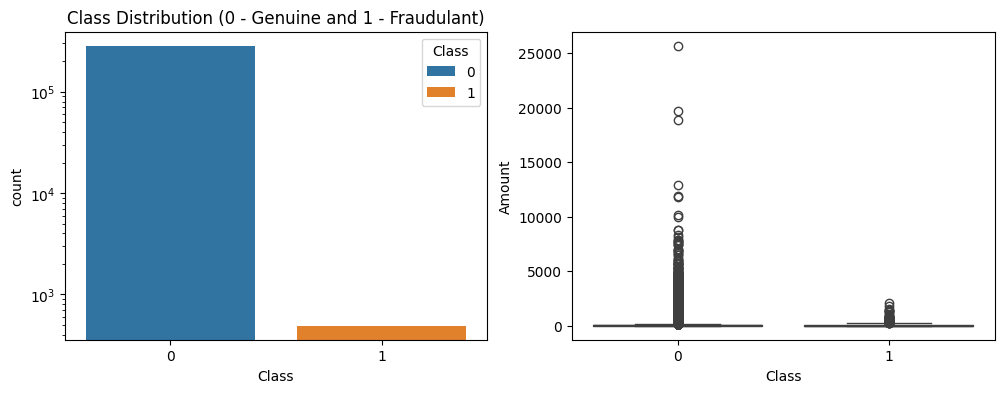

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Class', data=record_set_df, ax=axes[0], hue='Class')
axes[0].set_title('Class Distribution (0 - Genuine and 1 - Fraudulant)')
axes[0].set_yscale("log")

sns.boxplot(x='Class', y='Amount', data=record_set_df, ax=axes[1])

In [11]:
class_counts = record_set_df['Class'].value_counts()
fraud_count = class_counts.get(1, 0)
genuine_count = class_counts.get(0, 0)

print(f"Number of Fraudulent Transactions: {fraud_count}")
print(f"Number of Genuine Transactions: {genuine_count}")

Number of Fraudulent Transactions: 492
Number of Genuine Transactions: 284315


**Dataset** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud contains 284807 transactions made by european cardholdrs in Sept 2013 of which 492 are fradulent. The **class** column is the targer with 1=Fraud and 0=Genuine transaction.

## 4. Preprocessing the Credit Card Fraud Dataset



* Scale the Amount and Time values
* Split data to 60% train, 20% Valudation and 20% Test.
* We use genuine transactions to train the Autoencoder. The Autoencoder learns to regenrate the Genuine transactions behaviour. As the Autoencoder has not seen the fradulent dataset, so the Autoencoder should regenrate them poorly and flag them as Fradulent transaction



In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = record_set_df.drop('Class', axis=1)
y = record_set_df['Class']


# Convert DataFrame to numpy array
X_np = X.values
y_np = y.values

# Split data into training (60%), validation (20%), and testing (20%) sets
# First split: 80% for train+validation, 20% for test
X_train_val, X_test, y_train_val, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42, stratify=y_np)

# Second split: 60% for train, 20% for validation from the train_val set
# (0.25 * 0.8 = 0.2, so 25% of train_val set for validation)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

# Normalize 'Time' and 'Amount' features
time_col = X.columns.get_loc('Time')
amount_col = X.columns.get_loc('Amount')

scaler = StandardScaler()
X_train[:, [time_col, amount_col]] = scaler.fit_transform(X_train[:, [time_col, amount_col]])
X_val[:, [time_col, amount_col]]   = scaler.transform(X_val[:, [time_col, amount_col]])
X_test[:, [time_col, amount_col]] = scaler.fit_transform(X_test[:, [time_col, amount_col]])

#
# Filter X_train to only include genuine transactions for training the autoencoder
X_train_autoencoder = X_train[y_train == 0]
input_dim = X_train_autoencoder.shape[1]

# Print the shapes of the resulting datasets

print(f"Shape of X_train_autoencoder (genuine transactions for AE training): {X_train_autoencoder.shape}")
print(f"Input Dimensionality: {input_dim}")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train_autoencoder (genuine transactions for AE training): (170588, 30)
Input Dimensionality: 30
Shape of X_train: (170883, 30)
Shape of y_train: (170883,)
Shape of X_val: (56962, 30)
Shape of y_val: (56962,)
Shape of X_test: (56962, 30)
Shape of y_test: (56962,)


## 4. Autoencoder for Credit Card Fraud Detection

A symmetric deep autoencoder with input 30 dimensional to a low-dimension bottleneck and reconstruct back with `BatchNormalization` and `Dropout` for regularization. ReLU activations are used in the
hidden layers and a linear activation on the output layer, since the scaled input features are not bounded to `[0, 1]`.



### Model Design

Encoder: `input_dim → 20 → 14 → 7`--->  (bottleneck) ---> Decoder: `7 → 14 → 20 → input_dim`

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers # Import regularizers

# Define the autoencoder model using Keras Functional API
# input_dim is already available from the data preprocessing cell

encoding_dim = 7 # Bottleneck dimension

# Encoder
input_layer = keras.Input(shape=(input_dim,))

# Encoder layers with BatchNormalization and Dropout
encoder = layers.Dense(20, activation='relu', activity_regularizer=regularizers.l1(1e-6))(input_layer)
encoder = layers.BatchNormalization()(encoder)
encoder = layers.Dropout(0.2)(encoder)

encoder = layers.Dense(14, activation='relu')(encoder)
encoder = layers.BatchNormalization()(encoder)
#encoder = layers.Dropout(0.2)(encoder)

encoded = layers.Dense(encoding_dim, activation='relu')(encoder) # Bottleneck layer

# Decoder
decoder = layers.Dense(14, activation='relu')(encoded)
decoder = layers.BatchNormalization()(decoder)
decoder = layers.Dropout(0.2)(decoder)

decoder = layers.Dense(20, activation='relu')(decoder)
decoder = layers.BatchNormalization()(decoder)
decoder = layers.Dropout(0.2)(decoder)

decoded = layers.Dense(input_dim, activation='linear')(decoder) # Linear activation for output

# Autoencoder model
tf_autoencoder_deep = keras.Model(inputs=input_layer, outputs=decoded)

# Compile the model
tf_autoencoder_deep.compile(optimizer='adam', loss='mse') # MSE loss for reconstruction

tf_autoencoder_deep.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           294 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │           630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,333 (9.11 KB)

 Trainable params: 2,197 (8.58 KB)

 Non-trainable params: 136 (544.00 B)

### Training



*   The autoencoder is trained to minimize mean squared reconstruction error on genuine transactions only. with early stopping on validation loss .
*   



In [15]:
### Genuine valudation transactions only
X_val_autoencoder = X_val[y_val == 0]

callbacks = [
  keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
  keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

## Train the model

history = tf_autoencoder_deep.fit(
    X_train_autoencoder, X_train_autoencoder,
    epochs=60,
    batch_size=256,
    shuffle=True,
    validation_data=(X_val_autoencoder, X_val_autoencoder),
    callbacks=callbacks,
    verbose=2
)


Epoch 1/60
667/667 - 20s - 30ms/step - loss: 1.0213 - val_loss: 0.7341 - learning_rate: 0.0010
Epoch 2/60
667/667 - 2s - 3ms/step - loss: 0.7509 - val_loss: 0.6157 - learning_rate: 0.0010
Epoch 3/60
667/667 - 2s - 3ms/step - loss: 0.6828 - val_loss: 0.5512 - learning_rate: 0.0010
Epoch 4/60
667/667 - 2s - 3ms/step - loss: 0.6457 - val_loss: 0.5124 - learning_rate: 0.0010
Epoch 5/60
667/667 - 2s - 3ms/step - loss: 0.6228 - val_loss: 0.4904 - learning_rate: 0.0010
Epoch 6/60
667/667 - 2s - 3ms/step - loss: 0.6081 - val_loss: 0.4776 - learning_rate: 0.0010
Epoch 7/60
667/667 - 2s - 3ms/step - loss: 0.5994 - val_loss: 0.4668 - learning_rate: 0.0010
Epoch 8/60
667/667 - 2s - 3ms/step - loss: 0.5959 - val_loss: 0.4590 - learning_rate: 0.0010
Epoch 9/60
667/667 - 2s - 3ms/step - loss: 0.5905 - val_loss: 0.4482 - learning_rate: 0.0010
Epoch 10/60
667/667 - 2s - 3ms/step - loss: 0.5846 - val_loss: 0.4408 - learning_rate: 0.0010
Epoch 11/60
667/667 - 2s - 3ms/step - loss: 0.5826 - val_loss: 0.43

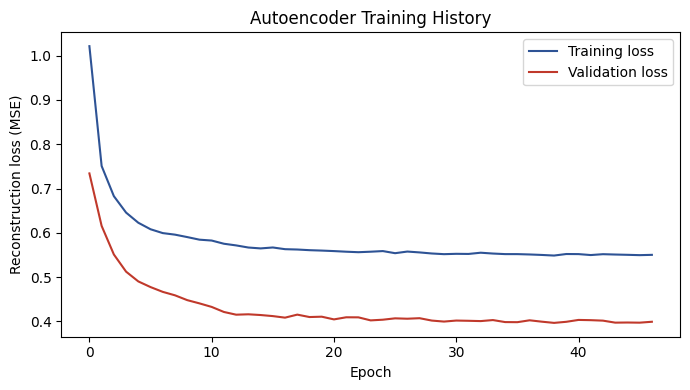

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history["loss"], label="Training loss", color="#2E5395")
ax.plot(history.history["val_loss"], label="Validation loss", color="#C0392B")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction loss (MSE)")
ax.set_title("Autoencoder Training History")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Detect anamolies

Genuine transactions
(which resemble the training distribution) should reconstruct with low error;
fraudulent transactions (unseen, structurally different) should reconstruct with
higher error.

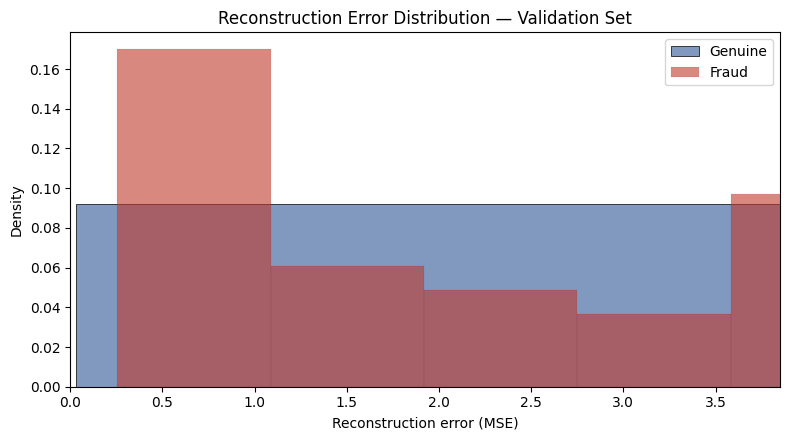

In [17]:
import numpy as np

def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=1)

val_errors = reconstruction_error(tf_autoencoder_deep, X_val)
test_errors = reconstruction_error(tf_autoencoder_deep, X_test)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(val_errors[y_val == 0], bins=80, stat="density", color="#2E5395",
             label="Genuine", alpha=0.6, ax=ax)
sns.histplot(val_errors[y_val == 1], bins=80, stat="density", color="#C0392B",
             label="Fraud", alpha=0.6, ax=ax)
ax.set_xlim(0, np.percentile(val_errors, 99.5))
ax.set_xlabel("Reconstruction error (MSE)")
ax.set_title("Reconstruction Error Distribution — Validation Set")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Classification Threshold

The classification threshold on reconstruction error is a tunable operating
point, not a fixed property of the model. It is selected on the **validation
set** (never the test set) by scanning candidate thresholds and choosing the one
that maximizes F1 score, which balances precision and recall for this heavily
imbalanced problem. The chosen threshold is then applied, unchanged, to the held-out test set.

In [18]:
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix, ConfusionMatrixDisplay

# We need the true labels for the validation set (y_val)
# and the reconstruction errors for the validation set (val_errors)

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_val, val_errors)

# Calculate F1 score for each threshold
f1_scores = (2 * precision * recall) / (precision + recall)

# Handle potential NaN values in f1_scores (where precision + recall = 0)
f1_scores = np.nan_to_num(f1_scores, nan=0.0)

# Find the threshold that maximizes the F1 score
# We need to ensure that thresholds has the same length as f1_scores. The precision_recall_curve
# returns thresholds[:-1] for precision and recall, meaning the last threshold is not included.
# To align, we need to consider f1_scores[:-1] as well for argmax or ensure thresholds match.
# Let's align by selecting the index from f1_scores that corresponds to the thresholds array.
optimal_idx = np.argmax(f1_scores)

# Ensure optimal_idx is within the bounds of thresholds
# If optimal_idx corresponds to the very last f1_score entry, which might not have a corresponding threshold
# in the `thresholds` array (as thresholds is one element shorter), we adjust it.
if optimal_idx == len(f1_scores) -1:
    optimal_threshold = thresholds[optimal_idx -1] # take the last valid threshold
else:
    optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Recalculate precision and recall at this specific optimal_threshold for reporting
y_val_pred_at_optimal = (val_errors >= optimal_threshold).astype(int)
cm_optimal = confusion_matrix(y_val, y_val_pred_at_optimal)

tp = cm_optimal[1, 1]
fp = cm_optimal[0, 1]
fn = cm_optimal[1, 0]

# Avoid division by zero when calculating precision, recall, and f1_score
current_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
current_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
current_f1_score = (2 * current_precision * current_recall) / (current_precision + current_recall) if (current_precision + current_recall) > 0 else 0.0

print(f"Precision at optimal threshold: {current_precision:.4f}")
print(f"Recall at optimal threshold: {current_recall:.4f}")
print(f"F1-score at optimal threshold: {current_f1_score:.4f}")

Optimal Threshold: 7.2878
Precision at optimal threshold: 0.3311
Recall at optimal threshold: 0.4949
F1-score at optimal threshold: 0.3968


/tmp/ipykernel_2674/1089811249.py:10: RuntimeWarning: invalid value encountered in divide
  f1_scores = (2 * precision * recall) / (precision + recall)


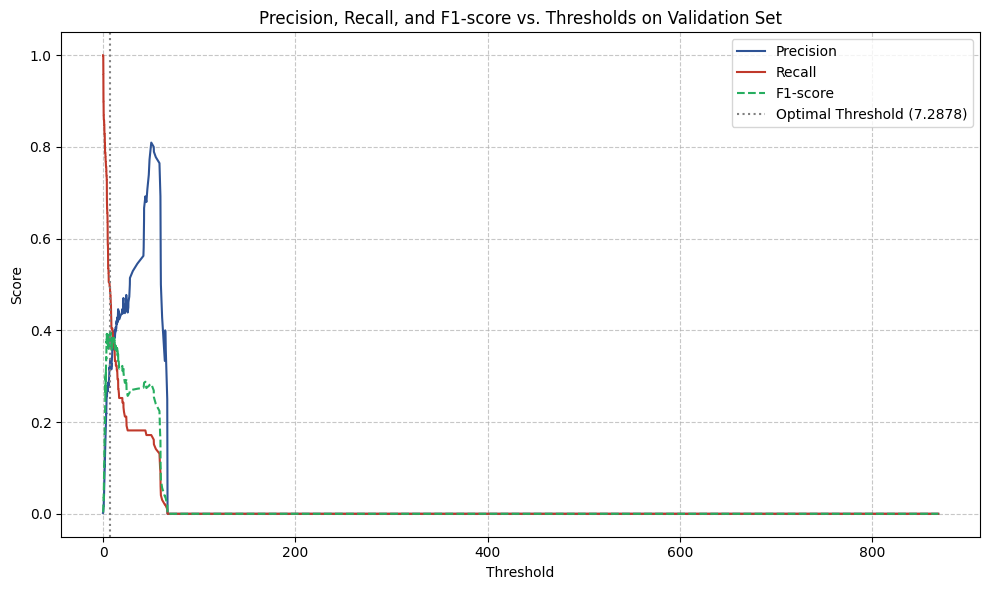

In [19]:
# Plot precision, recall, and F1-score against thresholds
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precision[:-1], label='Precision', color='#2E5395')
ax.plot(thresholds, recall[:-1], label='Recall', color='#C0392B')
ax.plot(thresholds, f1_scores[:-1], label='F1-score', color='#27AE60', linestyle='--')

# Mark the optimal threshold
ax.axvline(optimal_threshold, color='gray', linestyle=':', label=f'Optimal Threshold ({optimal_threshold:.4f})')

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1-score vs. Thresholds on Validation Set')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

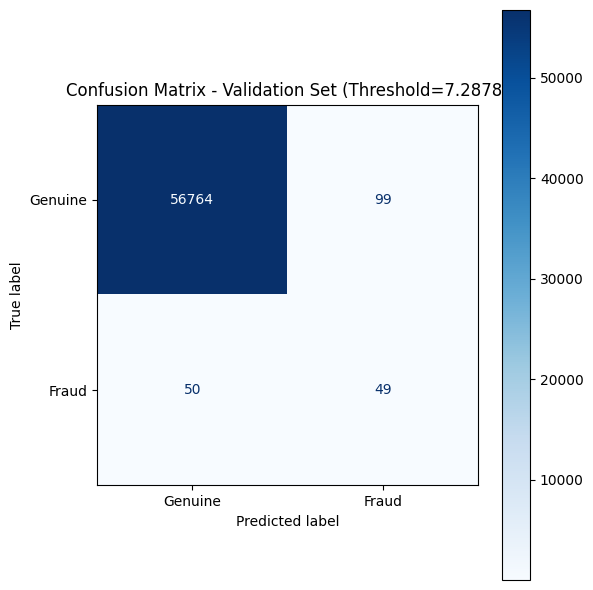

In [20]:
# Use the optimal threshold to classify anomalies in the validation set
y_val_pred = (val_errors >= optimal_threshold).astype(int)

# Calculate and display the confusion matrix for the validation set
cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine', 'Fraud'])
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title(f'Confusion Matrix - Validation Set (Threshold={optimal_threshold:.4f})')
plt.tight_layout()
plt.show()

## 7. Final Evaluation


In [24]:
from sklearn.metrics import classification_report

y_test_pred = (test_errors >= optimal_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, test_errors)
test_pr_auc = average_precision_score(y_test, test_errors)

print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test PR-AUC (Average Precision): {test_pr_auc:.4f}\n")
print(classification_report(y_test, y_test_pred, target_names=['Genuine', 'Fraud'], digits=4))

Test ROC-AUC: 0.9634
Test PR-AUC (Average Precision): 0.4335

              precision    recall  f1-score   support

     Genuine     0.9993    0.9984    0.9988     56864
       Fraud     0.3800    0.5816    0.4597        98

    accuracy                         0.9976     56962
   macro avg     0.6896    0.7900    0.7292     56962
weighted avg     0.9982    0.9976    0.9979     56962



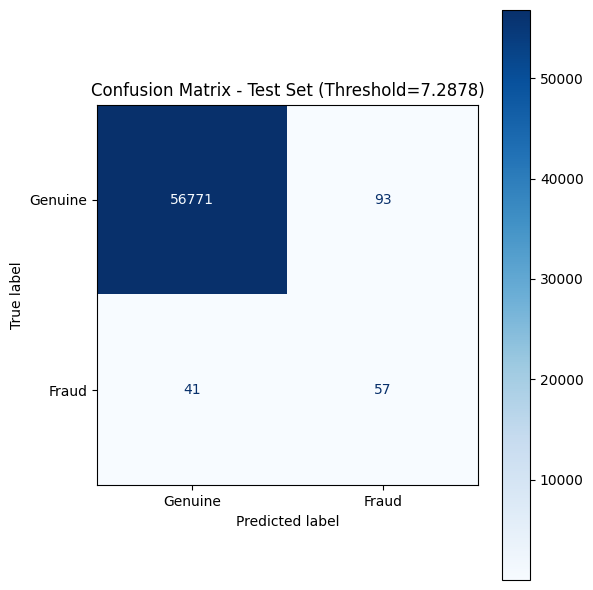

In [25]:
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Genuine', 'Fraud'])
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title(f'Confusion Matrix - Test Set (Threshold={optimal_threshold:.4f})')
plt.tight_layout()
plt.show()

- The model generalizes - ROC-AUC of 0.96 34 means it has strong ranking ability.
- PR-AUG = 0.4335 on a 0.17%  prevalene problem is a real, meaningful life over the ~0.0017 baseline.
- The model catches 58% of fraud while 62% of its fraud alerts are false alarms.
